In [13]:
import matplotlib.pyplot as plt
import sklearn.metrics
import numpy as np
import pandas as pd
import itertools
from scipy.stats import spearmanr
import seaborn as sns
from statistics import mean, stdev
from math import sqrt

In [14]:
for i, model_path in enumerate(["Qwen/Qwen2.5-Coder-0.5B", "Qwen/Qwen2.5-Coder-1.5B", "Qwen/Qwen2.5-Coder-3B", 
                          "Qwen/Qwen2.5-Coder-7B", "Qwen/Qwen2.5-Coder-14B", "Qwen/Qwen2.5-Coder-32B", "Qwen/Qwen2.5-72B-Instruct",
                          "deepseek-ai/deepseek-coder-1.3b-base", "deepseek-ai/deepseek-coder-6.7b-base", "deepseek-ai/deepseek-coder-33b-base",
                          "codellama/CodeLlama-7b-hf", "codellama/CodeLlama-13b-hf"]):
    df = pd.read_csv(f"../../result/RQ_Model_Arch_Size/{model_path.split('/')[-1]}.csv")
    print(f"ROC-AUC for {model_path}: {sklearn.metrics.roc_auc_score(df['vul_label'], df['new_score'])}")

ROC-AUC for Qwen/Qwen2.5-Coder-0.5B: 0.6102648401826484
ROC-AUC for Qwen/Qwen2.5-Coder-1.5B: 0.6138630136986302
ROC-AUC for Qwen/Qwen2.5-Coder-3B: 0.6532785388127852
ROC-AUC for Qwen/Qwen2.5-Coder-7B: 0.6400730593607307
ROC-AUC for Qwen/Qwen2.5-Coder-14B: 0.6408401826484018
ROC-AUC for Qwen/Qwen2.5-Coder-32B: 0.6557625570776255
ROC-AUC for Qwen/Qwen2.5-72B-Instruct: 0.5247741935483871
ROC-AUC for deepseek-ai/deepseek-coder-1.3b-base: 0.6045296803652969
ROC-AUC for deepseek-ai/deepseek-coder-6.7b-base: 0.6151050228310502
ROC-AUC for deepseek-ai/deepseek-coder-33b-base: 0.622593607305936
ROC-AUC for codellama/CodeLlama-7b-hf: 0.6385205479452055
ROC-AUC for codellama/CodeLlama-13b-hf: 0.6626849315068494


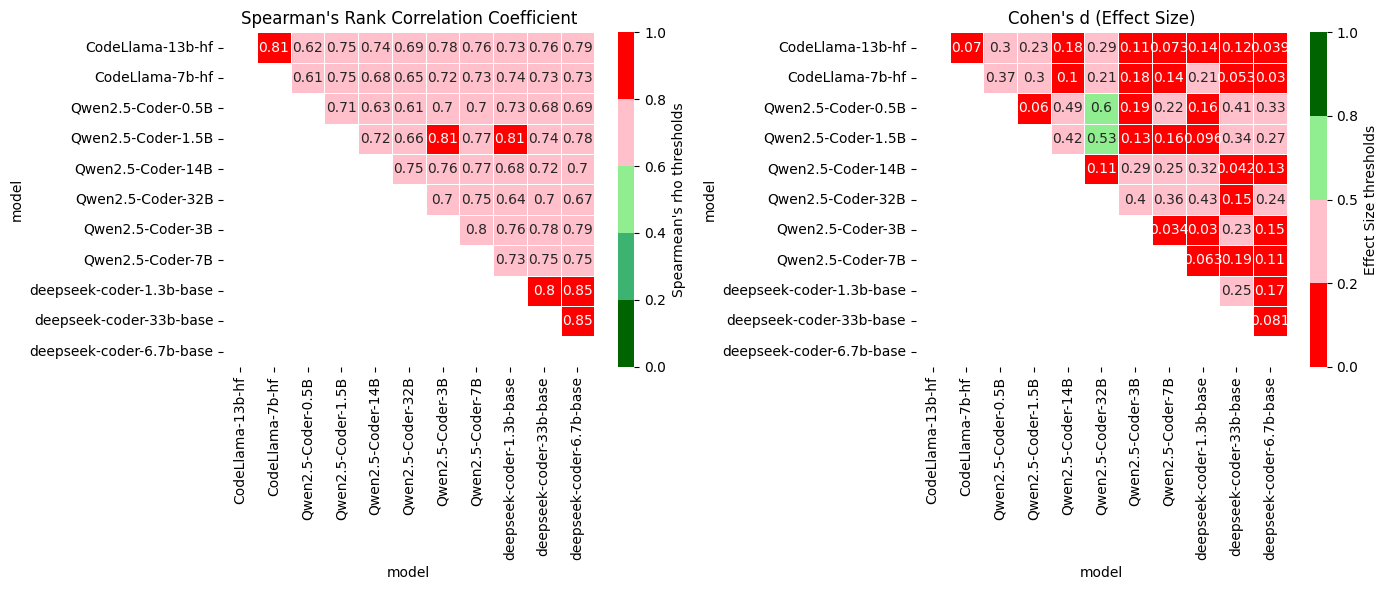

In [15]:
total_df = pd.DataFrame()
for model in ["Qwen2.5-Coder-0.5B", "Qwen2.5-Coder-1.5B", "Qwen2.5-Coder-3B", 
              "Qwen2.5-Coder-7B", "Qwen2.5-Coder-14B", "Qwen2.5-Coder-32B",
              "deepseek-coder-1.3b-base", "deepseek-coder-6.7b-base", "deepseek-coder-33b-base",
              "CodeLlama-7b-hf", "CodeLlama-13b-hf"]:
    df = pd.read_csv(f"../../result/RQ_Model_Arch_Size/{model}.csv")
    df["model"] = model
    total_df = pd.concat([total_df, df], ignore_index=True)

pivot = total_df.pivot_table(index=["file", "masked_line_no"],
                             columns="model",
                             values="new_score")
pivot = pivot.dropna()

spearmanr_matrix = pd.DataFrame(index=pivot.columns, columns=pivot.columns, dtype=float)

def cohens_d(x, y):
    return abs((mean(x) - mean(y)) / (sqrt((stdev(x) ** 2 + stdev(y) ** 2) / 2)))
cohens_d_matrix = pd.DataFrame(index=pivot.columns, columns=pivot.columns, dtype=float)

for first, second in list(itertools.combinations(pivot.columns, 2)):
    score_first = pivot[first].to_numpy()
    score_second = pivot[second].to_numpy()

    # Perform Spearman's rank correlation
    spearman_stat, spearman_p = spearmanr(score_first, score_second)
    spearmanr_matrix.loc[first, second] = spearman_stat

    # Calculate Cohen's d for effect size
    cohens_d_corr = cohens_d(score_first, score_second)
    cohens_d_matrix.loc[first, second] = cohens_d_corr

from matplotlib.colors import ListedColormap, BoundaryNorm
fig, axes = plt.subplots(ncols=2, figsize=(14, 6))

colors = ["darkgreen", "mediumseagreen", "lightgreen", "pink", "red"]
bounds = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))
sns.heatmap(spearmanr_matrix.astype(float), annot=True, cmap=cmap,
    norm=norm,
    cbar_kws={'ticks': bounds, 'label': 'Spearmean\'s rho thresholds'}, ax=axes[0], linewidth=.5)

colors = ["darkgreen", "lightgreen", "pink", "red"][-1::-1]  # Reverse the order for effect size
bounds = [0.0, 0.2, 0.5, 0.8, 1]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))
sns.heatmap(cohens_d_matrix.astype(float), annot=True, ax=axes[1], linewidth=.5, cmap=cmap,
    norm=norm,
    cbar_kws={'ticks': bounds, 'label': 'Effect Size thresholds'},)
axes[0].set_title("Spearman's Rank Correlation Coefficient")
axes[1].set_title("Cohen's d (Effect Size)")
plt.tight_layout()
plt.show()